# Hyperparameter Tuning — Random Forest

Tune the winning model (Random Forest) with `RandomizedSearchCV` (50 candidates x 5-fold CV),
then evaluate against the untuned baseline (test R2 = 0.9171) and save the improved model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


In [2]:
df = pd.read_csv('../data/processed/student_social_media_mental_health_clean.csv')

TARGET = 'Mental_Health_Score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
            'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ord_cols = ['Stress_Level']
cat_cols = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]), ord_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (3998, 12) | Test: (1000, 12)


## 1. Untuned baseline (reference)

In [3]:
baseline = Pipeline([('prep', preprocess),
                     ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
base_r2 = r2_score(y_test, base_pred)
base_rmse = root_mean_squared_error(y_test, base_pred)
base_mae = mean_absolute_error(y_test, base_pred)
print(f'Baseline (default RF)  Test R2: {base_r2:.4f} | MAE: {base_mae:.4f} | RMSE: {base_rmse:.4f}')


Baseline (default RF)  Test R2: 0.9171 | MAE: 0.2774 | RMSE: 0.3847


## 2. Randomized search

In [4]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.5],
    'model__bootstrap': [True, False],
}

search = RandomizedSearchCV(
    Pipeline([('prep', preprocess), 
    ('model', RandomForestRegressor(random_state=42, n_jobs=1))]),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(X_train, y_train)

print('Best CV R2:', round(search.best_score_, 4))
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')


Fitting 3 folds for each of 20 candidates, totalling 60 fits


Best CV R2: 0.8977
Best params:
  model__n_estimators: 100
  model__min_samples_split: 2
  model__min_samples_leaf: 1
  model__max_features: 0.5
  model__max_depth: 20
  model__bootstrap: False


## 3. Tuned model — test set evaluation

In [5]:
tuned = search.best_estimator_
tuned_pred = tuned.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_pred)
tuned_rmse = root_mean_squared_error(y_test, tuned_pred)
tuned_mae = mean_absolute_error(y_test, tuned_pred)

comparison = pd.DataFrame({
    'Model': ['Baseline (default RF)', 'Tuned RF'],
    'CV R2': [np.nan, search.best_score_],
    'Test R2': [base_r2, tuned_r2],
    'Test MAE': [base_mae, tuned_mae],
    'Test RMSE': [base_rmse, tuned_rmse],
})
print(comparison.round(4).to_string(index=False))
print(f'\nR2 improvement: {tuned_r2 - base_r2:+.4f} | RMSE improvement: {base_rmse - tuned_rmse:+.4f}')


                Model  CV R2  Test R2  Test MAE  Test RMSE
Baseline (default RF)    NaN   0.9171    0.2774     0.3847
             Tuned RF 0.8977   0.9331    0.2443     0.3455

R2 improvement: +0.0161 | RMSE improvement: +0.0392


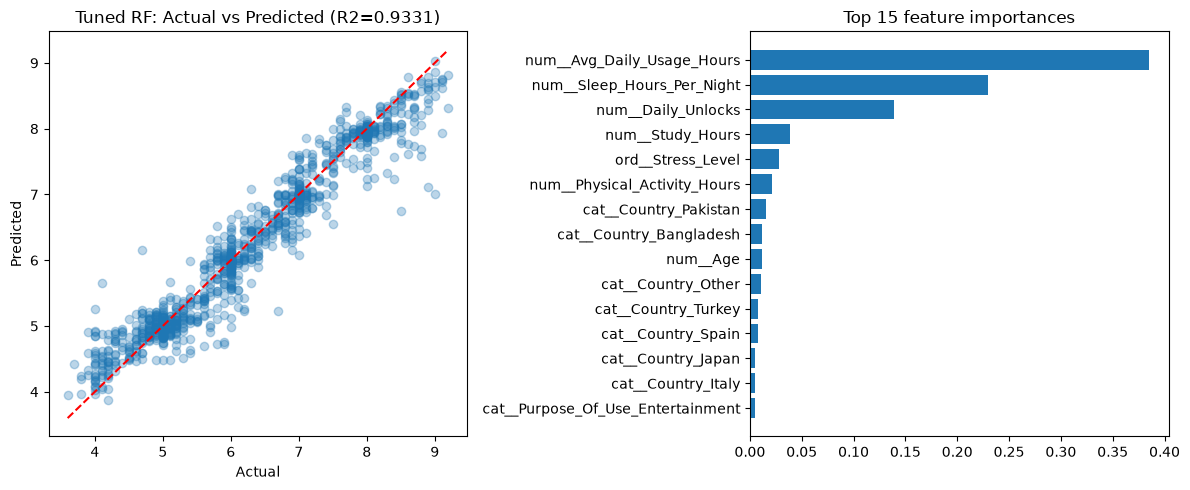

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, tuned_pred, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set(xlabel='Actual', ylabel='Predicted', title=f'Tuned RF: Actual vs Predicted (R2={tuned_r2:.4f})')

importances = pd.Series(tuned.named_steps['model'].feature_importances_,
                        index=tuned.named_steps['prep'].get_feature_names_out())
top = importances.sort_values(ascending=True).tail(15)
axes[1].barh(top.index, top.values)
axes[1].set_title('Top 15 feature importances')
plt.tight_layout()
plt.show()


## 4. Save the tuned model

In [7]:
joblib.dump(tuned, '../models/best_model.joblib')
with open('../models/best_model_params.json', 'w') as f:
    json.dump({'best_cv_r2': search.best_score_,
               'test_r2': tuned_r2, 'test_mae': tuned_mae, 'test_rmse': tuned_rmse,
               'params': {k: (v if v is not None else 'None') for k, v in search.best_params_.items()}},
              f, indent=2)
print('Saved tuned Random Forest -> ../models/best_model.joblib')


Saved tuned Random Forest -> ../models/best_model.joblib
